In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import mesa

from model import SocialGPModel
from rewards import (
    sample_children_with_corr,
    make_parent_and_children_cholesky2,
    build_corr_matrix_option1,
    build_corr_matrix_option2,
    build_corr_matrix_option3,
    _min_max,
)
from tqdm import tqdm

In [3]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [4]:
rho_variants_raw = {
    "perfectly_calibrated":  np.array([1.0,  0.6,  0.0,  -0.6]), # beliefs match the true environment
    "sign_flipped":          np.array([1.0, -0.6,  0.0,  0.6]),  # trusts the anti-correlated peer and avoids the helpful one
    "socially_agnostic":     np.array([1.0,  0.0,  0.0,  0.0]),  # ignores all social information
    "uniform_over_trusting": np.array([1.0,  0.6,  0.6,  0.6]),  # assumes everyone is positively aligned (over-generalization)
    "uniform_distrusting":   np.array([1.0, -0.6, -0.6,  -0.6]), # assumes everyone is anti-correlated (over-avoidance)
    "overconfident":         np.array([1.0,  0.9,  0.0,  -0.9]), # right signs, inflated strength; tests sensitivity to overconfidence
    "underconfident":        np.array([1.0,  0.2,  0.0,  -0.2]), # right signs, damped strength; tests robustness to weak beliefs
    "selective_trust":       np.array([1.0,  0.6,  0.0,  0.0]),  # trusts only the truly helpful peer; ignores the harmful one
    "selective_avoidance":   np.array([1.0,  0.0,  0.0,  -0.6]), # avoids only the harmful peer; ignores the helpful one
}

def project_rho_to_pd(rho_vec, max_norm=0.99):
    """Ensure the hub-correlation matrix stays PD by capping ‖rho_social‖₂."""
    rho_vec = np.asarray(rho_vec, dtype=float)
    social = rho_vec[1:]
    norm = np.linalg.norm(social)
    if norm >= max_norm and norm > 0:
        rho_vec[1:] = social * (max_norm / norm)
    return rho_vec

rho_variants = {name: project_rho_to_pd(v) for name, v in rho_variants_raw.items()}
rho_list = list(rho_variants.values())
rho_label_lookup = {tuple(v.round(6)): name for name, v in rho_variants.items()}

def label_rho(rho_arr):
    """Map a rho array to its scenario name; returns 'unknown' if not in the table."""
    key = tuple(np.asarray(rho_arr).round(6))  # tolerate float repr differences
    return rho_label_lookup.get(key, "unknown")

## Plot correlations

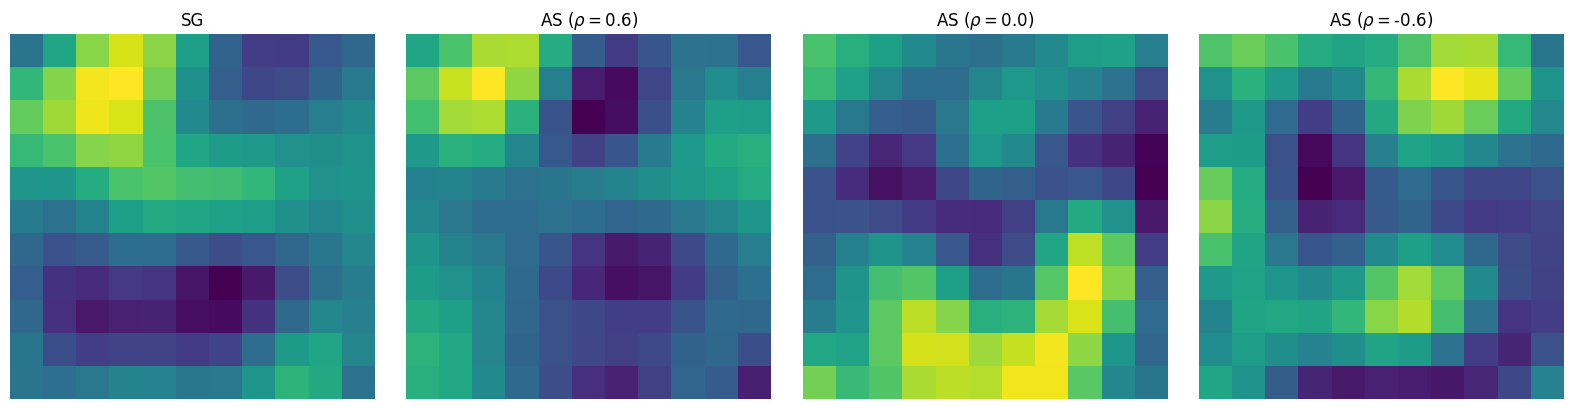

In [5]:
corr_matrix = build_corr_matrix_option1()  # parent + 3 children
n_children = corr_matrix.shape[0] - 1

seed = 0
a_rng = np.random.default_rng(seed)

grid_size = 11 # change resolution
parent, child_maps = make_parent_and_children_cholesky2(
    rng=a_rng,
    grid_size=grid_size,
    n_children=n_children + 1,
    length_scale=2.0,
    corr_matrix=corr_matrix,
)

# keep reward scale consistent with other sims
child_maps = [_min_max(c) - 0.5 for c in child_maps]

fig, axes = plt.subplots(1, len(child_maps) + 1, figsize=(4 * (len(child_maps) + 1), 4))

# parent
axes[0].imshow(_min_max(parent) - 0.5, origin='lower')
axes[0].set_title("SG")
axes[0].axis('off')

# children
for _corr, c, ax in zip([0.6, 0.0, -0.6], child_maps, axes[1:]):
    ax.imshow(c, origin='lower')
    ax.set_title(fr"AS ($\rho=${_corr})")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Run the model

In [6]:
m = SocialGPModel(
    n=n_children + 1,
    model_type="SG-ICM",
    child_maps=[parent] + child_maps,
    network_type="directed_one_to_four",
    rho=np.array([1.0, 0.6, 0.0, -0.6]),
    tau_sampling=True,  # tau=0.03
    beta_sampling=True,
    length_scale_sampling=True,
)

for _ in range(15):
    m.step()

results = m.datacollector.get_agent_vars_dataframe()

results.head(20)

choice    reward  cumulative_reward model_type       tau  neg_log_likelihood  last_choice_distance_private  avg_choice_distance_private  nearest_choice_distance_private  last_choice_distance_social  avg_choice_distance_social  nearest_choice_distance_social
Step AgentID                                                                                                                                                                                                                                                                    
1    1        (10, 4)  1.904984           1.904984     SG-ICM  0.002614        0.000000e+00                      0.000000                     0.000000                         0.000000                     0.000000                    0.000000                        0.000000
     2         (2, 1)  0.065885           0.065885         AS  0.002614        0.000000e+00                      0.000000                     0.000000                         0.000000                     0.000000                    0.000000                        0.000000
     3         (2, 5)  0.135761           0.135761         AS  0.002614        0.000000e+00                      0.000000                     0.000000                         0.000000                     0.000000                    0.000000                        0.000000
     4         (6, 6) -0.145363          -0.145363         AS  0.002614        0.000000e+00                      0.000000                     0.000000                         0.000000                     0.000000                    0.000000                        0.000000
2    1        (10, 4)  1.895380           3.300364     SG-ICM  0.002614        1.200013e-10                      0.000000                     0.000000                         0.000000                     7.026132                    7.026132                        4.472136
     2         (3, 1)  0.004657          -0.429458         AS  0.002614        4.787492e+00                      1.000000                     1.000000                         1.000000                     0.000000                    0.000000                        0.000000
     3        (2, 10) -0.144941          -0.509180         AS  0.002614        4.787492e+00                      5.000000                     5.000000                         5.000000                     0.000000                    0.000000                        0.000000
     4        (8, 10) -0.019477          -0.664840         AS  0.002614        4.787492e+00                      4.472136                     4.472136                         4.472136                     0.000000                    0.000000                        0.000000
3    1        (10, 4)  1.905881           4.706245     SG-ICM  0.002614        1.200013e-10                      0.000000                     0.000000                         0.000000                     7.980109                    7.503121                        4.472136
     2         (9, 1)  0.419849          -0.509609         AS  0.002614        4.779123e+00                      6.000000                     6.500000                         6.000000                     0.000000                    0.000000                        0.000000
     3         (5, 5) -0.403498          -1.412678         AS  0.002614        4.779123e+00                      5.830952                     4.415476                         3.000000                     0.000000                    0.000000                        0.000000
     4         (3, 7)  0.238763          -0.926077         AS  0.002614        4.779123e+00                      5.830952                     4.496615                         3.162278                     0.000000                    0.000000                        0.000000
4    1        (10, 4)  1.883829           6.090074     SG-ICM  0.002614        1.200013e-10                      0.000000                     0.000000                         0.000000          

In [7]:
R = build_corr_matrix_option1()

param_grid = {
    "n": 4,
    "model_type": "SG-ICM",
    "observation_noise_private": 0.0001,
    "observation_noise_social":  0.0001,
    "tau_sampling": True,
    "beta_sampling": True,
    "length_scale_sampling": True,
    "length_scale_is_identical": True,
    "seed": list(range(1000)),
    "network_type": "directed_one_to_four",
    "rho": rho_list,
    "corr_matrix": [R]
}

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=param_grid,
    iterations=1,
    max_steps=15,
    number_processes=None,
    data_collection_period=1,
    display_progress=True,
)

batch_results = pd.DataFrame(batch_results)

  0%|          | 0/9000 [00:00<?, ?it/s]

In [8]:
batch_results = pd.DataFrame(batch_results)
batch_results['rho_label'] = batch_results['rho'].apply(label_rho)
batch_results.head()


,RunId,iteration,Step,n,model_type,observation_noise_private,observation_noise_social,tau_sampling,beta_sampling,length_scale_sampling,length_scale_is_identical,seed,network_type,rho,corr_matrix,avg_cumulative_reward,avg_reward,AgentID,choice,reward,cumulative_reward,tau,neg_log_likelihood,last_choice_distance_private,avg_choice_distance_private,nearest_choice_distance_private,last_choice_distance_social,avg_choice_distance_social,nearest_choice_distance_social,rho_label
0,5,0,0,4,SG-ICM,0.0001,0.0001,True,True,True,True,0,directed_one_to_four,"[1.0, 0.7000357133746821, 0.0, -0.700035713374...","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.443456,0.443456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,overconfident
1,5,0,1,4,SG-ICM,0.0001,0.0001,True,True,True,True,0,directed_one_to_four,"[1.0, 0.7000357133746821, 0.0, -0.700035713374...","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.701827,0.350914,1.0,"(9, 9)",0.654450,0.654450,0.01244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,overconfident
2,5,0,1,4,AS,0.0001,0.0001,True,True,True,True,0,directed_one_to_four,"[1.0, 0.7000357133746821, 0.0, -0.700035713374...","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.701827,0.350914,2.0,"(5, 4)",0.561097,0.561097,0.01244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,overconfident
3,5,0,1,4,AS,0.0001,0.0001,True,True,True,True,0,directed_one_to_four,"[1.0, 0.7000357133746821, 0.0, -0.700035713374...","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.701827,0.350914,3.0,"(9, 8)",0.327141,0.327141,0.01244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,overconfident
4,5,0,1,4,AS,0.0001,0.0001,True,True,True,True,0,directed_one_to_four,"[1.0, 0.7000357133746821, 0.0, -0.700035713374...","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.701827,0.350914,4.0,"(3, 10)",0.231135,0.231135,0.01244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,overconfident


In [9]:
def plot_reward(df, y_col="reward", keep_labels=None, figsize=(9, 5)):
    plot_df = df[df.model_type == "SG-ICM"].copy()
    if keep_labels:
        plot_df = plot_df[plot_df["rho_label"].isin(keep_labels)]
        hue_order = keep_labels
    else:
        hue_order = sorted(plot_df["rho_label"].unique())

    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=plot_df,
        x="Step",
        y=y_col,
        hue="rho_label",
        hue_order=hue_order,
        ax=ax,
    )
    ax.set_title(f"{y_col.replace('_', ' ').title()} under assumed task correlations")
    ax.set_xlabel("Step")
    ax.set_ylabel(y_col.replace("_", " ").title())
    ax.legend(
        title="Assumed correlation structure",
        bbox_to_anchor=(1.02, 0.5), loc="center left",
        borderaxespad=0,
    )
    plt.tight_layout()
    plt.show()

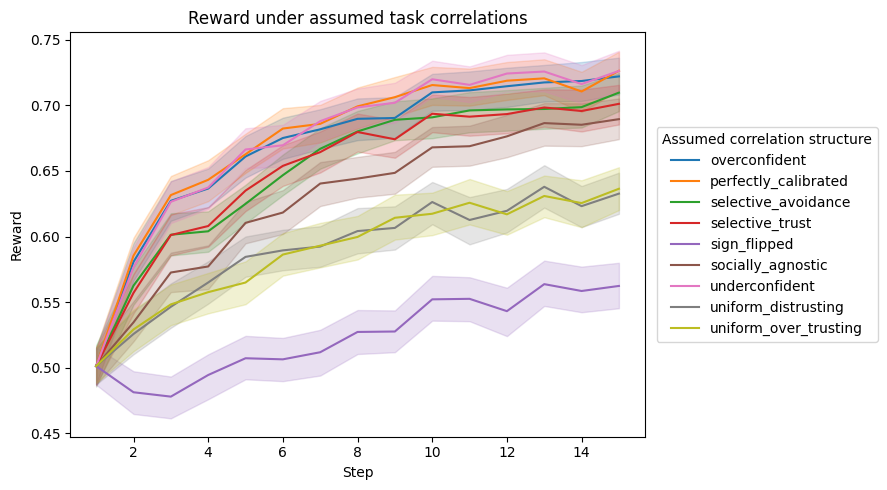

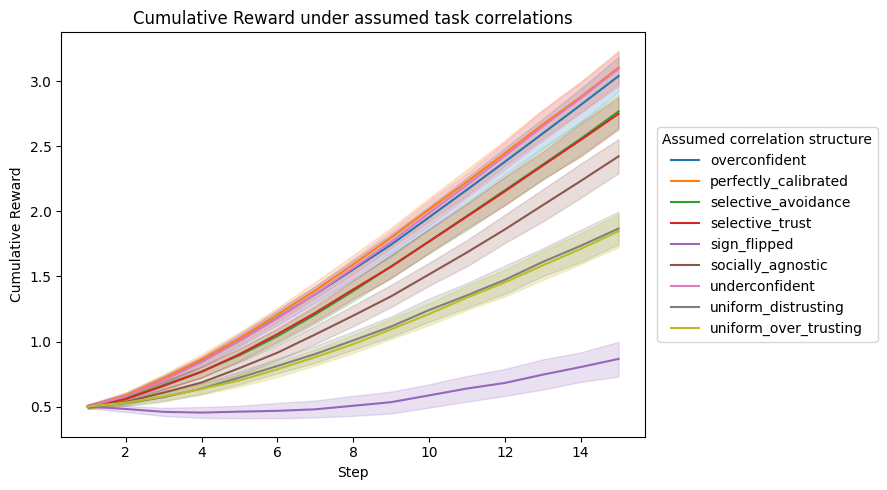

In [10]:
# All lines:
plot_reward(batch_results, y_col="reward")
plot_reward(batch_results, y_col="cumulative_reward")

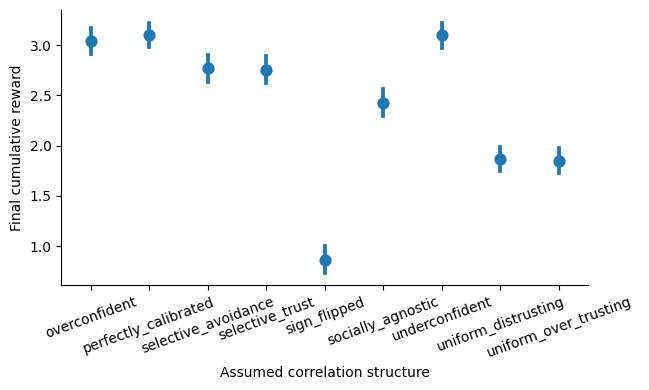

In [11]:
def plot_final_cumreward_catplot(df, x='rho_label'):
    plot_df = df[df.model_type == "SG-ICM"].copy()
    final_step = plot_df.groupby(['RunId', 'iteration'])['Step'].transform('max')
    last = plot_df[plot_df['Step'] == final_step].copy()

    sns.catplot(
        data=last,
        kind='point', # 'box',
        x=x,
        y='cumulative_reward',
        order=sorted(last[x].unique()),
        height=4,
        aspect=1.6,
        linestyle='none'
    )
    plt.xticks(rotation=20)
    plt.xlabel('Assumed correlation structure')
    plt.ylabel('Final cumulative reward')
    plt.tight_layout()
    plt.show()

plot_final_cumreward_catplot(batch_results)


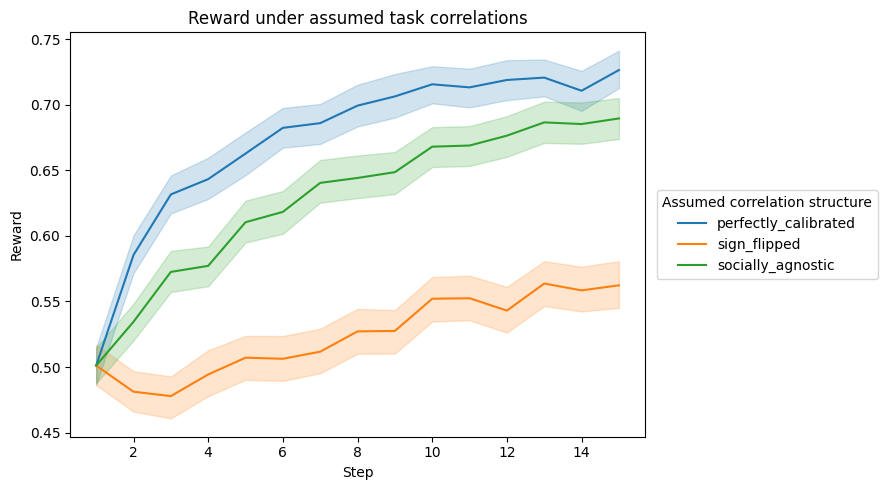

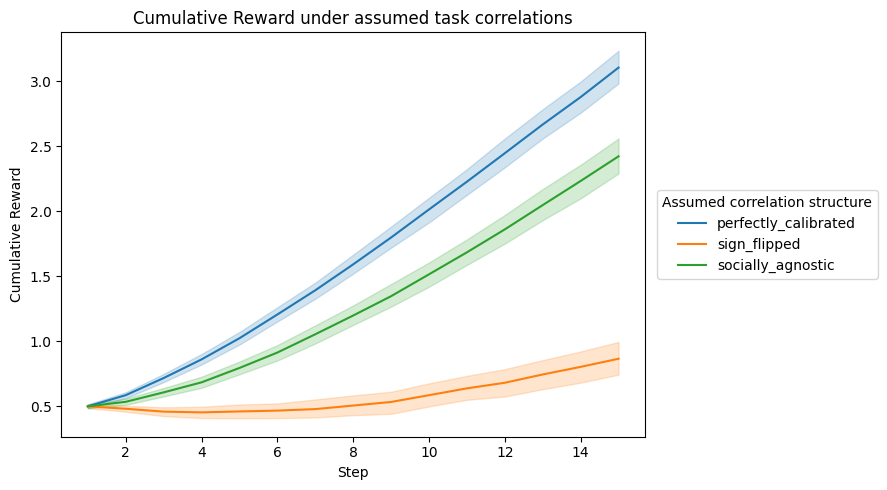

In [12]:
# Custom subset: 
my_subset = [
    "perfectly_calibrated",  # beliefs match the true environment
    "sign_flipped",          # trusts the anti-correlated peer and avoids the helpful one
    "socially_agnostic",     # ignores all social information
    ]
plot_reward(batch_results, y_col="reward", keep_labels=my_subset)
plot_reward(batch_results, y_col="cumulative_reward", keep_labels=my_subset)

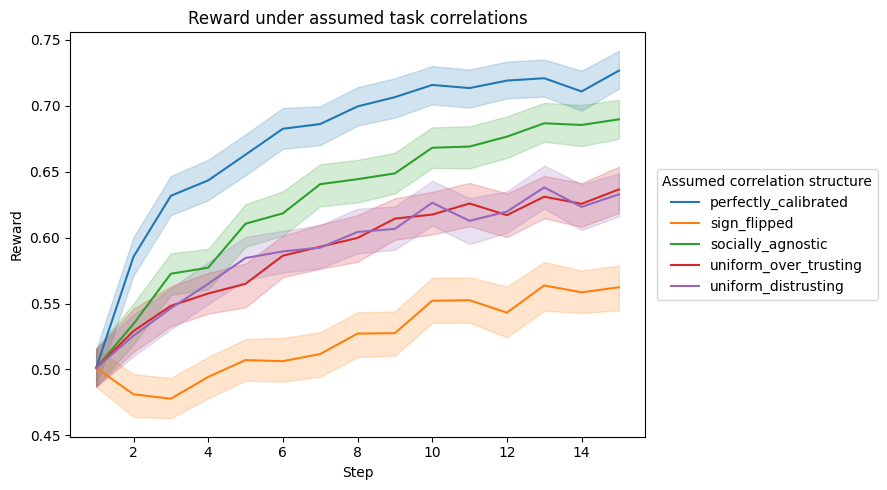

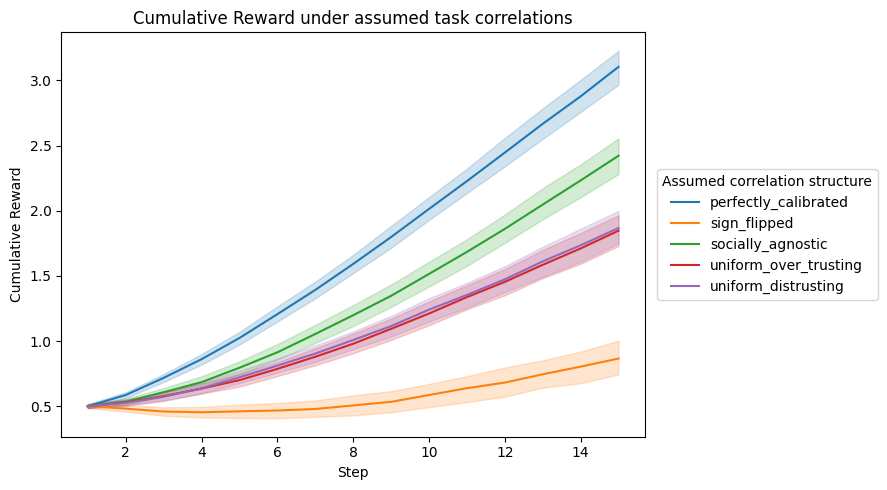

In [13]:
# Custom subset:
my_subset = [
    "perfectly_calibrated",  # beliefs match the true environment
    "sign_flipped",          # trusts the anti-correlated peer and avoids the helpful one
    "socially_agnostic",     # ignores all social information
    "uniform_over_trusting", # assumes everyone is positively aligned (over-generalization) 
    "uniform_distrusting"    # assumes everyone is anti-correlated (over-avoidance)
    ]
plot_reward(batch_results, y_col="reward", keep_labels=my_subset)
plot_reward(batch_results, y_col="cumulative_reward", keep_labels=my_subset)

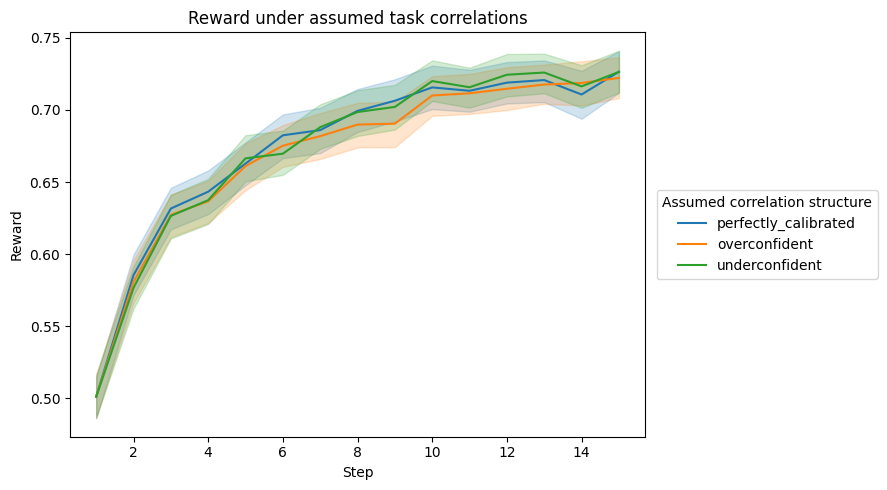

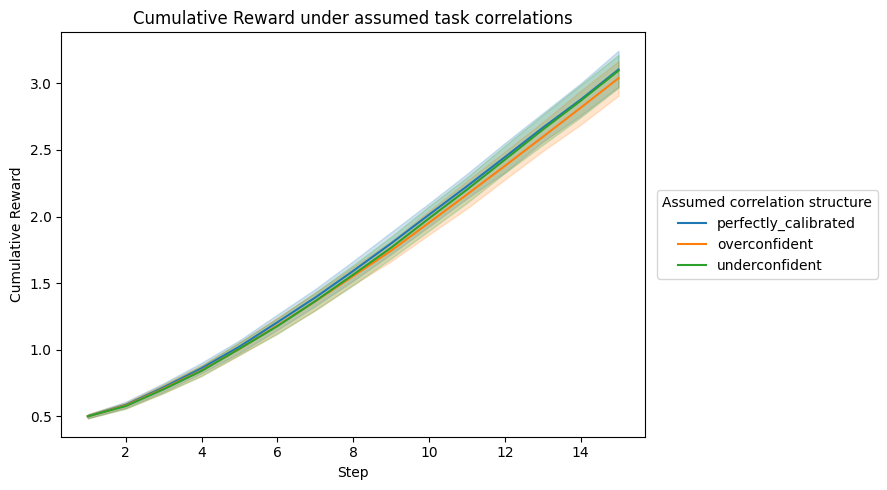

In [14]:
# Custom subset: knows who to trust or distrust, but the magnitude is not corect
my_subset = [
    "perfectly_calibrated",  # beliefs match the true environment
    "overconfident",          # right signs, inflated strength; tests sensitivity to overconfidence
    "underconfident",         # right signs, damped strength; tests robustness to weak beliefs
    ]
plot_reward(batch_results, y_col="reward", keep_labels=my_subset)
plot_reward(batch_results, y_col="cumulative_reward", keep_labels=my_subset)

# “aligned vs sign-flipped vs agnostic” to highlight correctness of belief.

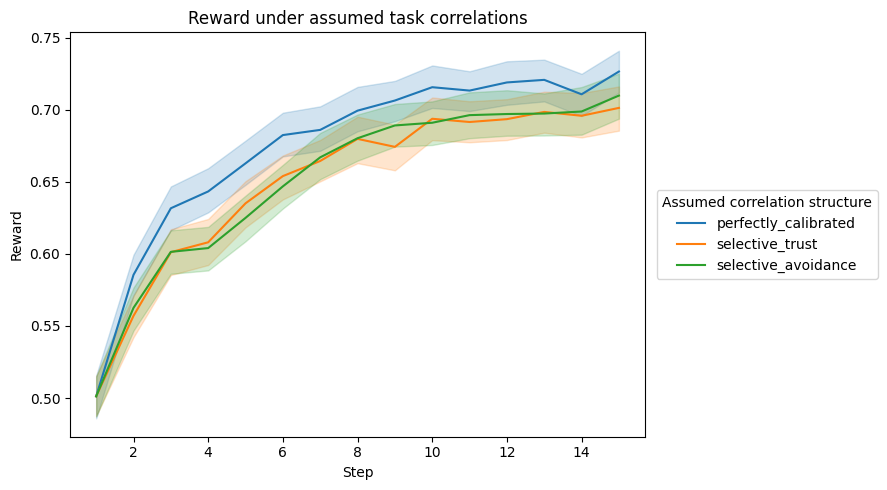

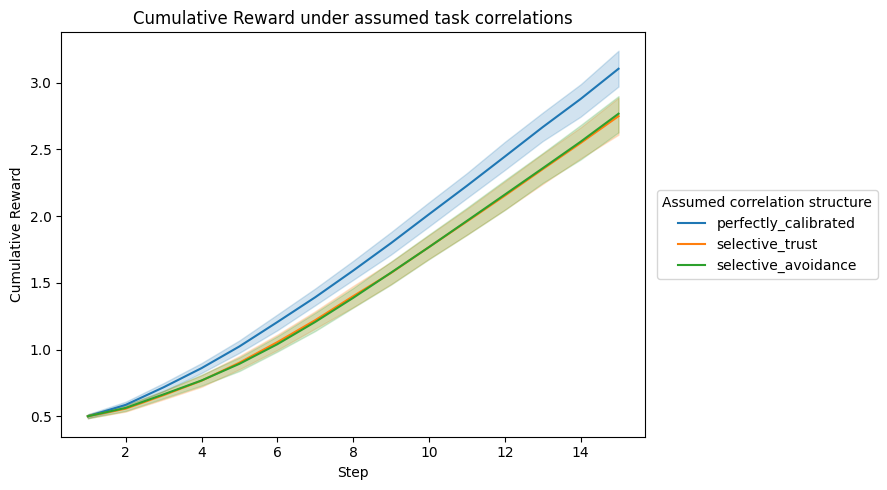

In [15]:
# Custom subset: [trust/distrust] the correct person, and ignore the one that should be [distrust/trust]
my_subset = [
    "perfectly_calibrated",  # beliefs match the true environment
    "selective_trust",        # trusts only the truly helpful peer; ignores the harmful one
    "selective_avoidance"    # avoids only the harmful peer; ignores the helpful one
    ]
plot_reward(batch_results, y_col="reward", keep_labels=my_subset)
plot_reward(batch_results, y_col="cumulative_reward", keep_labels=my_subset)

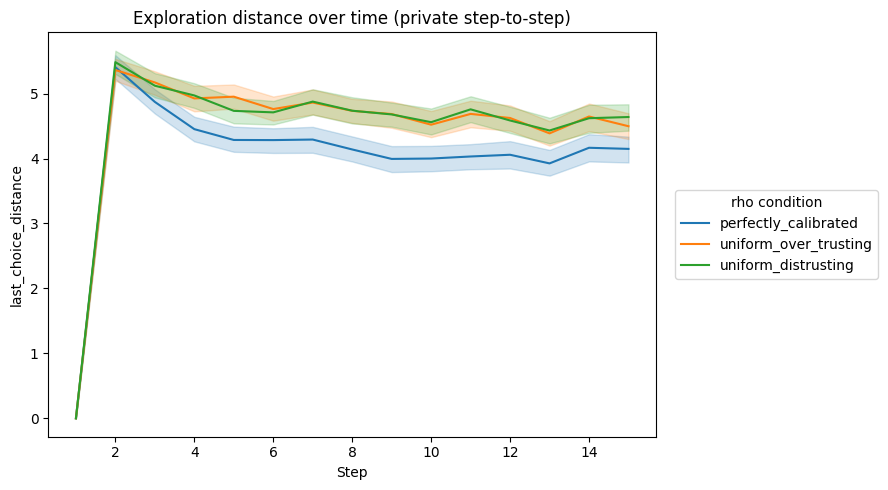

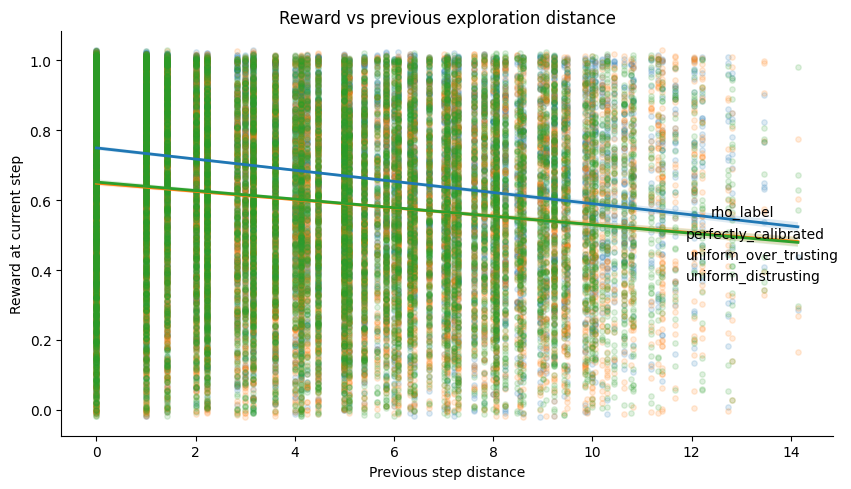

perfectly_calibrated slope(prev_dist_priv→reward)= -0.015970866251547908 intercept= 0.7496793316548056
uniform_over_trusting slope(prev_dist_priv→reward)= -0.011828091887715038 intercept= 0.6488053575082945
uniform_distrusting slope(prev_dist_priv→reward)= -0.01221885905365394 intercept= 0.6519505996167614


In [18]:
from sklearn.linear_model import LinearRegression

# choose which rho conditions to analyze
keep_labels = ["perfectly_calibrated", "uniform_over_trusting", "uniform_distrusting"]

required_cols = [
    "last_choice_distance_private",
    "last_choice_distance_social",
    "reward",
    "Step",
    "rho_label",
    "model_type",
]

df = batch_results.copy()
df = df[(df["model_type"] == "SG-ICM") & (df["rho_label"].isin(keep_labels))].copy()
group_cols = [c for c in ["RunId", "iteration", "AgentID"] if c in df.columns]
df = df.sort_values(group_cols + ["Step"])

# distance at t-1 predicts reward at t
df["prev_dist_priv"] = df.groupby(group_cols)["last_choice_distance_private"].shift(1)
df["prev_dist_soc"] = df.groupby(group_cols)["last_choice_distance_social"].shift(1)

df_lag = df.dropna(subset=["prev_dist_priv", "reward"]).copy()

# Distance over time
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=df,
    x="Step",
    y="last_choice_distance_private",
    hue="rho_label",
    hue_order=keep_labels,
    errorbar="ci",
)
plt.title("Exploration distance over time (private step-to-step)")
plt.xlabel("Step")
plt.ylabel("last_choice_distance")
plt.legend(title="rho condition", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()

# Reward vs previous distance
g = sns.lmplot(
    data=df_lag,
    x="prev_dist_priv",
    y="reward",
    hue="rho_label",
    hue_order=keep_labels,
    height=5,
    aspect=1.3,
    scatter_kws={"alpha": 0.15, "s": 15},
    line_kws={"linewidth": 2},
)
g.set_axis_labels("Previous step distance", "Reward at current step")
plt.title("Reward vs previous exploration distance")
plt.tight_layout()
plt.show()

for label in keep_labels:
    sub = df_lag[df_lag["rho_label"] == label]
    X = sub[["prev_dist_priv"]].to_numpy()
    y = sub["reward"].to_numpy()
    lr = LinearRegression().fit(X, y)
    print(label, "slope(prev_dist_priv→reward)=", float(lr.coef_[0]), "intercept=", float(lr.intercept_))


## Explore $\rho$ Magnitude Sensitivity

In [66]:
rho_list_2_agents = [
    np.array([1.0,  np.round(i, 2)])
     for i in np.linspace(-0.95, 0.95, 39)
]

rho_list_2_agents[-2:]

[array([1. , 0.9]), array([1.  , 0.95])]

In [67]:
param_grid = {
    "n": 2,
    "model_type": "SG-ICM",
    "observation_noise_private": 0.0001,
    "observation_noise_social":  0.0001,
    "tau_sampling": True,
    "beta_sampling": True,
    "length_scale_sampling": True,
    "length_scale_is_identical": True,
    "seed": list(range(2000)),
    "network_type": "directed_one_to_four",
    "rho": rho_list_2_agents,
    "corr_matrix": [np.array([[1.0, 0.6], [0.6, 1.0]]),
                    np.array([[1.0, -0.6], [-0.6, 1.0]])]
}

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=param_grid,
    iterations=1,
    max_steps=15,
    number_processes=None,
    data_collection_period=1,
    display_progress=True,
)

batch_results = pd.DataFrame(batch_results)

  0%|          | 0/156000 [00:00<?, ?it/s]

In [70]:
mask = (batch_results.Step == 15) & (batch_results.model_type == "SG-ICM")
rho_sensitivity_df = batch_results[mask].reset_index()
rho_sensitivity_df['rho_value'] = [v[1] for v in rho_sensitivity_df['rho'].values]
rho_sensitivity_df['corr_value'] = [v[0, 1] for v in rho_sensitivity_df['corr_matrix'].values]

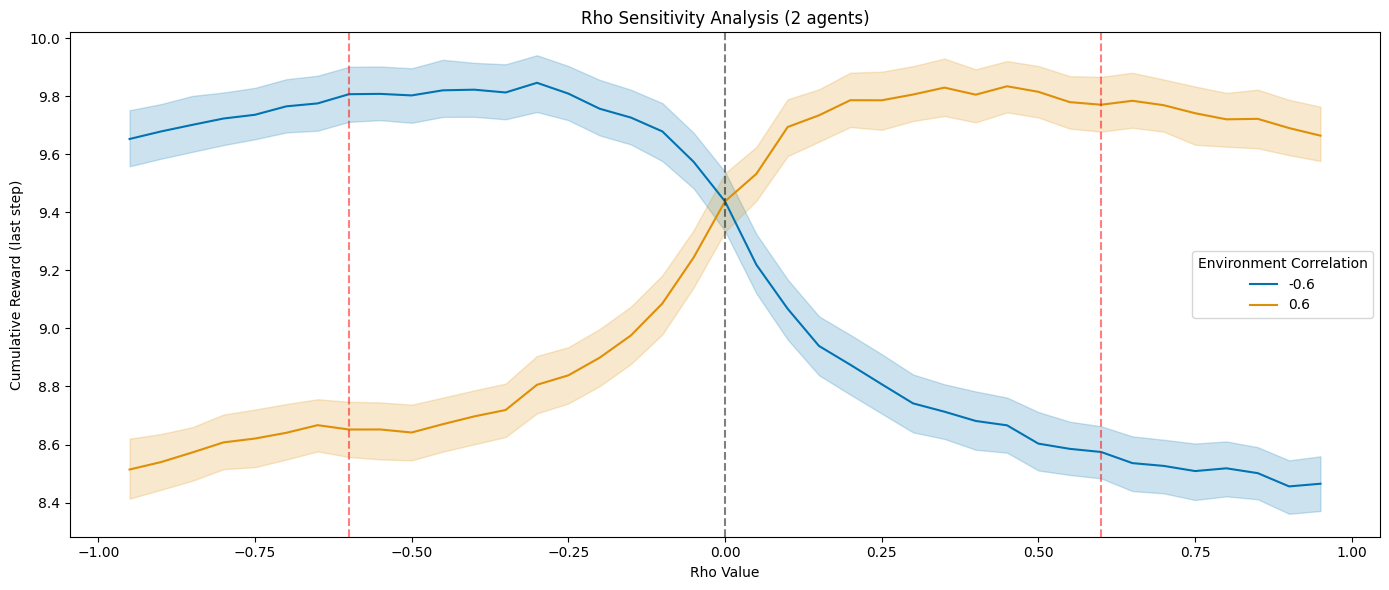

In [69]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=rho_sensitivity_df,
    x="rho_value",
    y="cumulative_reward",
    hue="corr_value",
    palette=sns.color_palette("colorblind", 2),
)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)

for val in [-0.6, 0.6]:
    plt.axvline(x=val, color='red', linestyle='--', alpha=0.5)



plt.title("Rho Sensitivity Analysis (2 agents)")
plt.xlabel("Rho Value")
plt.ylabel("Cumulative Reward (last step)")
plt.legend(title="Environment Correlation")

plt.tight_layout()
plt.show()